In [86]:
import pandas as pd
import numpy as np

In [87]:
df= pd.read_csv("imbalanced_data.csv")

In [88]:
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [89]:
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

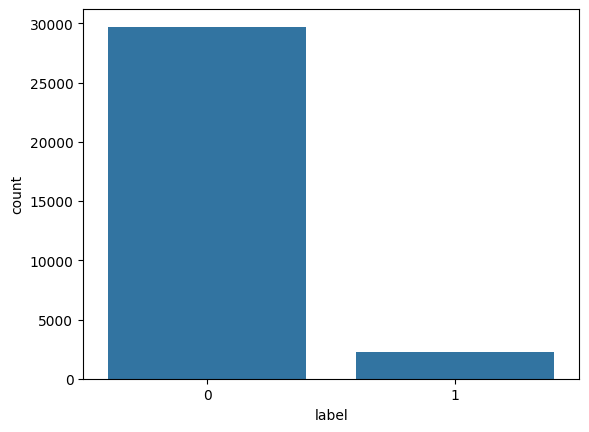

In [90]:
sns.countplot(x='label',data=df)

In [91]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sidda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [92]:
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [93]:
def data_cleaning(words):
    words = str(words).lower()
    words = re.sub('\[.*?\]', '', words)
    words = re.sub('https?://\S+|www\.\S+', '', words)
    words = re.sub('<.*?>+', '', words)
    words = re.sub('[%s]' % re.escape(string.punctuation), '', words)
    words = re.sub('\n', '', words)
    words = re.sub('\w*\d\w*', '', words)
    words = [word for word in words.split(' ') if words not in stopword]
    words=" ".join(words)
    words = [stemmer.stem(words) for word in words.split(' ')]
    words=" ".join(words)

    return words

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\2883962192.py:3: SyntaxWarning: invalid escape sequence '\['
  words = re.sub('\[.*?\]', '', words)
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\2883962192.py:4: SyntaxWarning: invalid escape sequence '\S'
  words = re.sub('https?://\S+|www\.\S+', '', words)
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\2883962192.py:8: SyntaxWarning: invalid escape sequence '\w'
  words = re.sub('\w*\d\w*', '', words)


In [94]:
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [95]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [96]:
df.head()

,id,label,tweet
0,1,0,user when a father is dysfunctional and is so...
1,2,0,user user thanks for lyft credit i cant use ca...
2,3,0,bihday your majesti bihday your majesti ...
3,4,0,model i love u take with u all the time in u...
4,5,0,factsguide society now motiv factsguide s...


In [97]:
df["tweet"][1]

'user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    disapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdx    dis

In [98]:
df.iloc[0]['tweet']

' user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run  user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction   run

In [99]:
x = df['tweet']
y = df['label']

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 42)

print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

23971 23971
7991 7991


In [102]:
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [103]:
## Count unique Vocabulary
all_words = [word for sentence in df.tweet for word in sentence.split()]

unique_words = set(all_words)
# unique_words = (all_words)
vocab_size = len(unique_words)

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 45410


In [104]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

In [105]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [106]:
sequences = tokenizer.texts_to_sequences(x_train)

In [107]:
sequences_matrix = pad_sequences(sequences,maxlen=max_len)

In [108]:
sequences_matrix

array([[    0,     0,     0, ...,    27,     4,    97],
       [   98, 14667,     7, ...,     2,  1447,    20],
       [    0,     0,     0, ...,    12,   154, 37282],
       ...,
       [  981,   518,  2096, ...,   123,     2, 22950],
       [    0,     0,     0, ...,   858, 28719,   501],
       [    0,     0,     0, ...,    58,    91,  1722]],
      shape=(23971, 300), dtype=int32)

In [109]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()
model.add(Embedding(max_words, 100, input_length=max_len))
model.add(SimpleRNN(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

model.summary()

c:\Users\sidda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [110]:
from tensorflow.keras.optimizers import RMSprop

In [111]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

In [112]:
history = model.fit(sequences_matrix,y_train,batch_size=128,epochs = 1,validation_split=0.2)

150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8843 - loss: 0.3330 - val_accuracy: 0.9293 - val_loss: 0.2610


In [113]:
x_test

12227     user âmy mom says my smile is captivatingâ...
14709    in  days i will be meeting my sisnlaw couney b...
19319    hating the conservative homophobes using this ...
4308     awee if this doesnt  scream   friday acewellst...
24055     fathersday  fatherã¢ââs day god ãâ« tony a...
                               ...                        
21818    she wolf ðº ð goodnight boanoite tribe lo...
7363     user yassss finger clicks she gonna be a fine ...
26986    cant wait to be floating in my pool next weeke...
7698     or heâs super excited because he just found ...
30232    a gold coin from spain shine shinny love   spa...
Name: tweet, Length: 7991, dtype: object

In [114]:
test_sequences = tokenizer.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

In [115]:
accr = model.evaluate(test_sequences_matrix,y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9300 - loss: 0.2578


In [116]:
rnn_prediction = model.predict(test_sequences_matrix)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step


In [117]:
rnn_prediction

array([[0.03960808],
       [0.04555752],
       [0.03912506],
       ...,
       [0.0417146 ],
       [0.040885  ],
       [0.04075323]], shape=(7991, 1), dtype=float32)

In [118]:
res = []
for prediction in rnn_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [119]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,res))

[[7432    0]
 [ 559    0]]


In [120]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [121]:
model.save("model.h5")

In [122]:
import keras

In [123]:
import os
print(os.getcwd())

c:\Users\sidda\Desktop\RNN


In [124]:
load_model=keras.models.load_model("model.h5")

In [125]:
with open('tokenizer.pickle', 'rb') as handle:
    load_tokenizer = pickle.load(handle)

In [126]:
# prediction

In [127]:
# Let's test our model on custom data.
test = 'i love this movie'

def clean_text(text):
    print(text)
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    print(text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

test=[clean_text(test)]
print(test)

seq = load_tokenizer.texts_to_sequences(test)
padded = pad_sequences(seq, maxlen=300)
# print(seq)

pred = load_model.predict(padded)

print("pred", pred)
if pred<0.5:
    print("no hate")
else:
    print("hate and abusive")


i love this movie
i love this movie
['love movi']


<>:7: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:7: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:12: SyntaxWarning: invalid escape sequence '\w'
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\1638456624.py:7: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\1638456624.py:8: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
C:\Users\sidda\AppData\Local\Temp\ipykernel_9740\1638456624.py:12: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
pred [[0.03923203]]
no hate


In [129]:
# Save model
model.save("model.keras")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)